# FAseg — Dataset Sanity Check

Reads **one fixed sample** from the synthetic dataset and renders it
under all three stage configurations so you can visually verify that
TOF filtering and domain randomisation are applied correctly.

A fixed random seed is set before every `__getitem__` call so that
noise pairing is deterministic and differences between stages are
attributable purely to the augmentation parameters.

In [61]:
import os, sys, copy
import random
import numpy as np
import matplotlib.pyplot as plt

_NB_DIR = os.path.abspath('')
if os.path.basename(_NB_DIR) == 'scripts':
    _project_root = os.path.dirname(_NB_DIR)
else:
    _project_root = _NB_DIR
_src_root = os.path.join(_project_root, 'src')
if _src_root not in sys.path:
    sys.path.insert(0, _src_root)

from faseg.data.dataset import LimbArrayDataset
os.makedirs(os.path.join(_project_root, 'outputs'), exist_ok=True)
print(f'Project root : {_project_root}')

Project root : /data/projects/AgentWork/FAseg for github


In [ ]:
# =========================================================================
# Paths — same as pretrain_stage_full.ipynb
# =========================================================================
DATA_DIR  = os.path.join(_project_root, 'datasets', 'simulated')
NOISE_DIR = os.path.join(_project_root, 'datasets', 'noise')
LABEL_DIR = os.path.join(_project_root, 'datasets', 'labels')

# =========================================================================
# Common parameters shared by all stages
# =========================================================================
COMMON = dict(
    data_scale      = 2670658846720 * (1 / 15),
    noise_scale     = 1.0,
    load_noise      = True,
    noise_dt        = 4e-8,
    sim_dt          = 2.4e-7,
    sim_nt          = 876,
    net_nt          = 876,
    interval        = 32,
    normalize_need  = True,
    shift_enabled   = True,
    crop_enabled    = True,
    crop_rows       = (64, 448),
    crop_cols       = (300, 684),
    augment_flip    = False,
    further_scaling = 1.0,
)

SAMPLE_IDX = 5 # with limited samples in "datasets/simulated", here only support 0~7
print(f'Will inspect sample idx = {SAMPLE_IDX}')

Will inspect sample idx = 5


In [63]:
# =========================================================================
# Helper: create a dataset for one stage & fetch SAMPLE_IDX with fixed seed
# =========================================================================
def fetch_sample(stage_name, **stage_overrides):
    """Return (img_2d, mask_2d) as numpy arrays for visualisation."""
    kwargs = {**COMMON, **stage_overrides}
    ds = LimbArrayDataset(DATA_DIR, NOISE_DIR, LABEL_DIR, **kwargs)

    rng_state = random.getstate()
    np_rng_state = np.random.get_state()
    random.seed(42)
    np.random.seed(42)

    img, mask = ds[SAMPLE_IDX]

    random.setstate(rng_state)
    np.random.set_state(np_rng_state)

    img_np  = img.squeeze(0).numpy()
    mask_np = mask.squeeze(0).numpy()

    print(f'{stage_name:12s}  img [{img_np.min():+.3f}, {img_np.max():+.3f}]  '
          f'mask unique={np.unique(mask_np)}  TOF={kwargs.get("TOF_filt_enabled")}  '
          f'filt_strength={kwargs.get("filt_strength","-")}  '
          f'gap_prob={kwargs.get("gap_prob","-")}')
    return img_np, mask_np

In [64]:
# =========================================================================
# Fetch one sample under each of the three stage configs
# =========================================================================
img_s1, mask_s1 = fetch_sample(
    'Stage 1',
    TOF_filt_enabled = False,
    gap_prob         = 0.0,
)

img_s2, mask_s2 = fetch_sample(
    'Stage 2',
    TOF_filt_enabled = True,
    filt_strength    = 3.2,
    filt_max_ratio   = 1.0,
    gap_prob         = 0.0,
)

img_s3, mask_s3 = fetch_sample(
    'Stage 3',
    TOF_filt_enabled = True,
    filt_strength    = 3.2,
    filt_max_ratio   = 1.0,
    gap_prob         = 0.75,
    gap_max_ratio    = 0.8,
    gap_max_grid     = (20, 40),
)

Stage 1       img [-1.000, +1.000]  mask unique=[0. 1.]  TOF=False  filt_strength=-  gap_prob=0.0
Stage 2       img [-1.000, +1.000]  mask unique=[0. 1.]  TOF=True  filt_strength=3.2  gap_prob=0.0
Stage 3       img [-1.000, +1.000]  mask unique=[0. 1.]  TOF=True  filt_strength=3.2  gap_prob=0.75


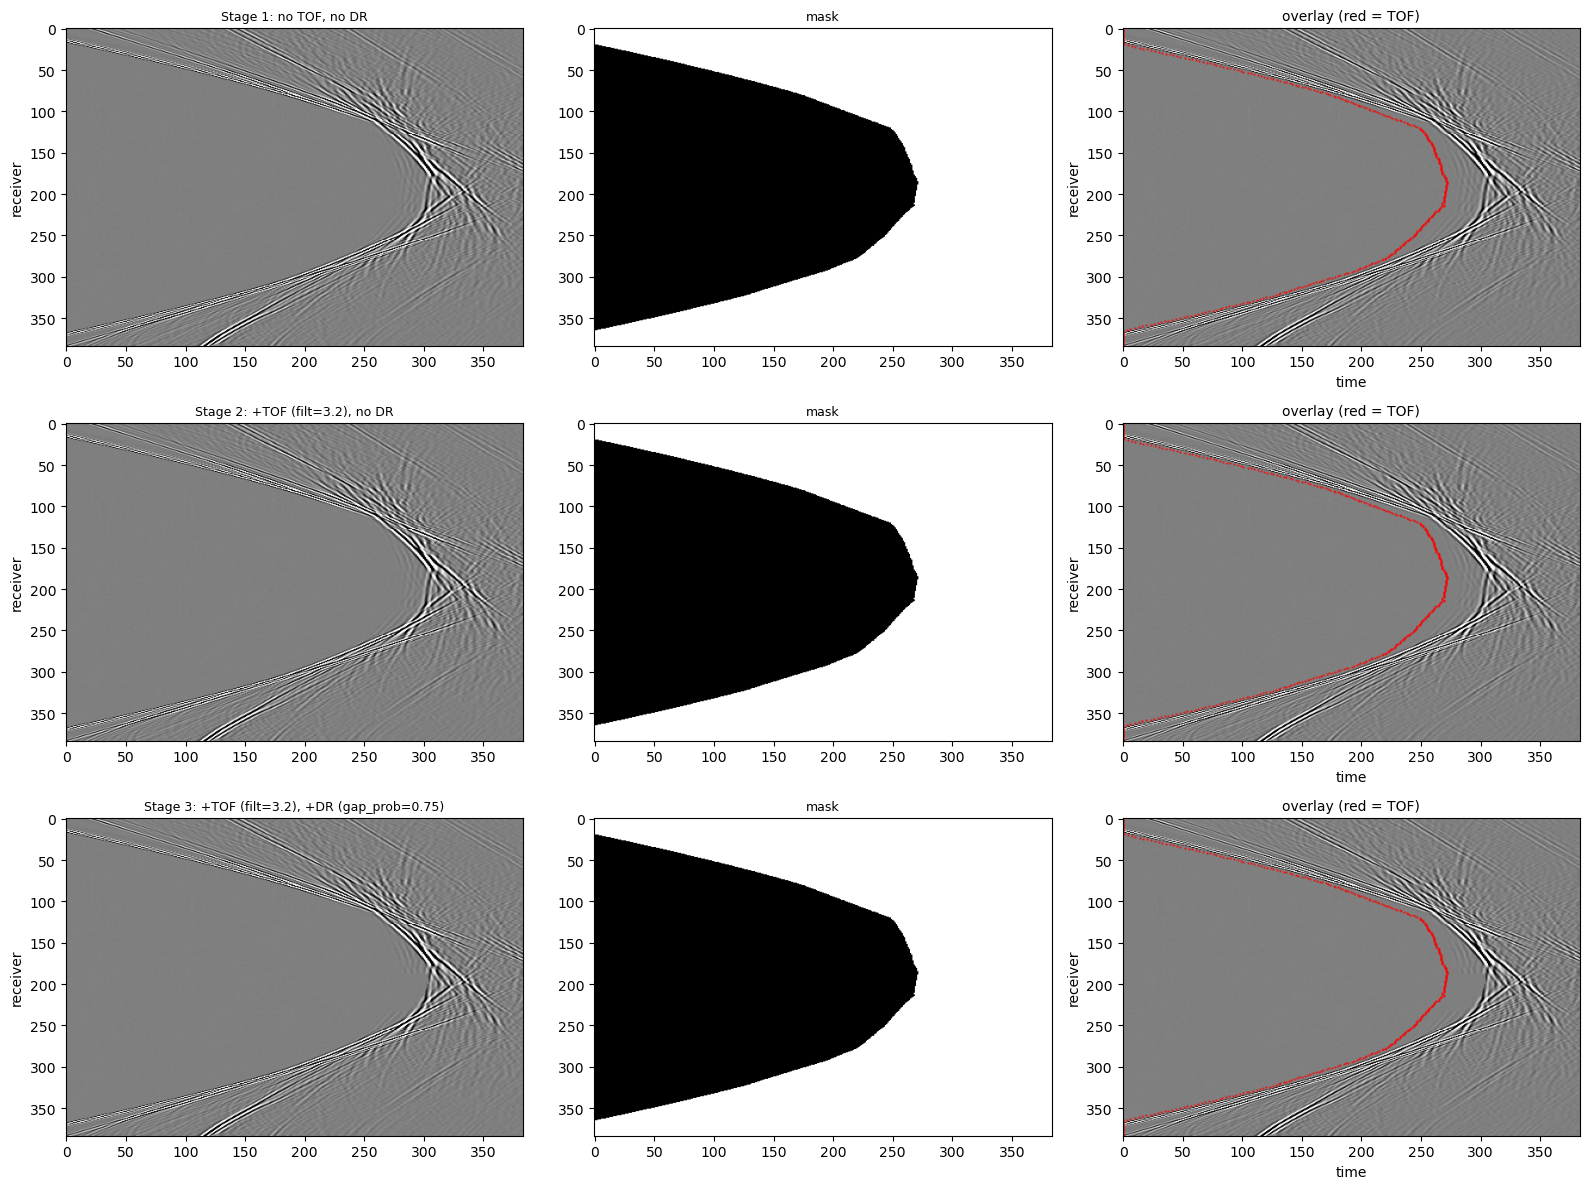

Saved to outputs/dataset_sanity_check.png


In [65]:
# =========================================================================
# Figure 1 — 3 rows x 3 cols:  signal | mask | overlay
# =========================================================================
def first_one_overlay(ax, img, mask, title, vmin=-0.5, vmax=0.5):
    ax.imshow(img, aspect='auto', cmap='gray', vmin=vmin, vmax=vmax)
    first_cols = mask.argmax(axis=1)
    rows = np.arange(mask.shape[0])
    valid = mask.max(axis=1) > 0
    ax.plot(first_cols[valid], rows[valid], '.', color='red', markersize=1.5, alpha=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('time'); ax.set_ylabel('receiver')

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
stages = [
    (img_s1, mask_s1, 'Stage 1: no TOF, no DR'),
    (img_s2, mask_s2, 'Stage 2: +TOF (filt=3.2), no DR'),
    (img_s3, mask_s3, 'Stage 3: +TOF (filt=3.2), +DR (gap_prob=0.75)'),
]
vmax = max(np.abs(img_s1).max(), np.abs(img_s2).max(), np.abs(img_s3).max()) * 0.3
for row_idx, (img, mask, title) in enumerate(stages):
    axes[row_idx, 0].imshow(img, aspect='auto', cmap='gray', vmin=-vmax, vmax=vmax)
    axes[row_idx, 0].set_title(title, fontsize=9)
    axes[row_idx, 0].set_ylabel('receiver')
    axes[row_idx, 1].imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
    axes[row_idx, 1].set_title('mask', fontsize=9)
    first_one_overlay(axes[row_idx, 2], img, mask, 'overlay (red = TOF)', vmin=-vmax, vmax=vmax)
plt.tight_layout()
plt.savefig(os.path.join(_project_root, 'outputs', 'dataset_sanity_check.png'), dpi=150)
plt.show()
print('Saved to outputs/dataset_sanity_check.png')

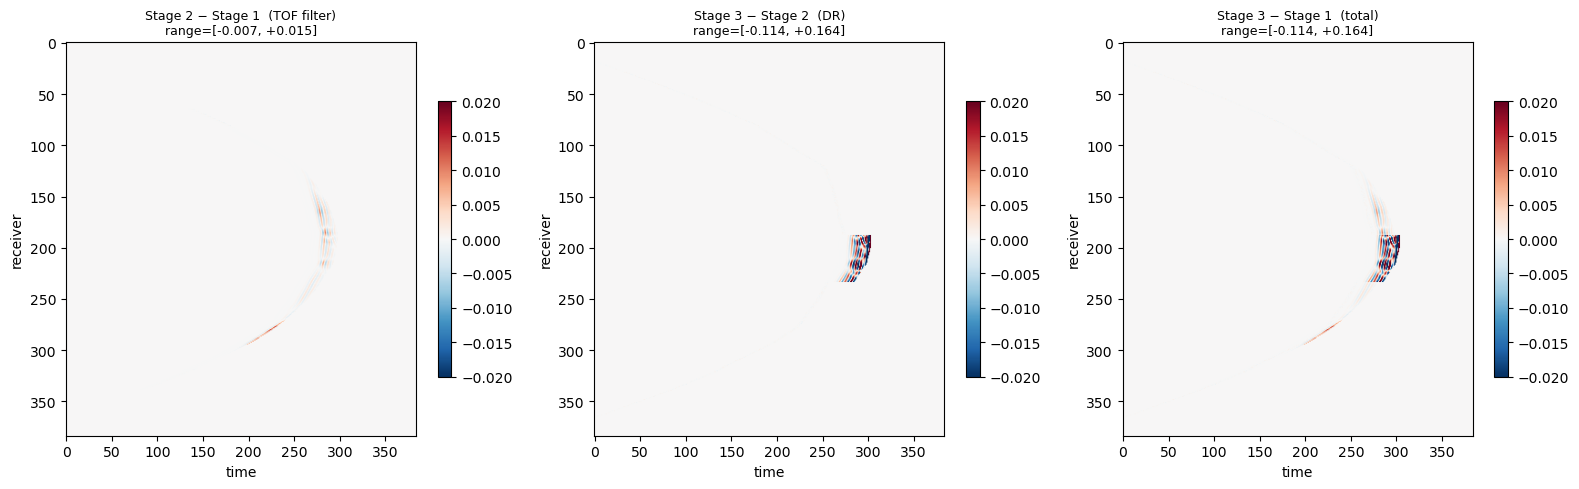

Saved to outputs/dataset_diff_maps.png


In [66]:
# =========================================================================
# Figure 2 — Diff maps, each with its OWN colour scale
# =========================================================================
diff_s2_s1 = img_s2 - img_s1
diff_s3_s2 = img_s3 - img_s2
diff_s3_s1 = img_s3 - img_s1

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, diff, title in zip(
    axes,
    [diff_s2_s1, diff_s3_s2, diff_s3_s1],
    ['Stage 2 − Stage 1  (TOF filter)', 'Stage 3 − Stage 2  (DR)', 'Stage 3 − Stage 1  (total)']
):
    # dmax = np.abs(diff).max() if np.abs(diff).max() > 0 else 1.0
    dmax = 0.02
    im = ax.imshow(diff, aspect='auto', cmap='RdBu_r', vmin=-dmax, vmax=dmax)
    ax.set_title(f'{title}\nrange=[{diff.min():+.3f}, {diff.max():+.3f}]', fontsize=9)
    ax.set_xlabel('time'); ax.set_ylabel('receiver')
    plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.savefig(os.path.join(_project_root, 'outputs', 'dataset_diff_maps.png'), dpi=150)
plt.show()
print('Saved to outputs/dataset_diff_maps.png')

---
### What you should see

**Figure 1 (3×3 panel)**
- Stage 1 → Stage 2: signal should look subtly attenuated near the TOF boundary
- Stage 2 → Stage 3: signal may show gap artifacts (dark horizontal bands) or speckle noise
- **Mask must be identical across all three rows** — if not, there is a bug

**Figure 2 (diff maps with independent colour scales)**
- Left panel (S2−S1): should show a blue band along the TOF front — signal reduced by the filter.  Its own colour scale makes it visible even if DR artifacts are larger in magnitude.
- Middle panel (S3−S2): shows DR artifacts (gap / speckle) independently.

**Figure 3 (row profile)**
- Blue line (S1) should be HIGHER than orange line (S2) near the TOF position.
- The printed attenuation ratio should be ~0.31 with ``filt_strength=3.2``.
- If it is ~1.0, the filter is not working.


In [67]:
# =========================================================================
# Save Stage 1/2/3 images & masks to a MATLAB-readable .mat file
# =========================================================================
from scipy.io import savemat

mat_path = os.path.join(_project_root, 'outputs', 'dataset_sanity_check.mat')
savemat(mat_path, {
    'img_s1':  img_s1,  'mask_s1': mask_s1,
    'img_s2':  img_s2,  'mask_s2': mask_s2,
    'img_s3':  img_s3,  'mask_s3': mask_s3,
})
print(f'Saved to {mat_path}')
print(f'  img_s1 {img_s1.shape}  mask_s1 {mask_s1.shape}')
print(f'  img_s2 {img_s2.shape}  mask_s2 {mask_s2.shape}')
print(f'  img_s3 {img_s3.shape}  mask_s3 {mask_s3.shape}')
print('  Load in MATLAB:  S = load("dataset_sanity_check.mat");')
print('                   % -> S.img_s1, S.mask_s1, S.img_s2, S.mask_s2, S.img_s3, S.mask_s3')


Saved to /data/projects/AgentWork/FAseg for github/outputs/dataset_sanity_check.mat
  img_s1 (384, 384)  mask_s1 (384, 384)
  img_s2 (384, 384)  mask_s2 (384, 384)
  img_s3 (384, 384)  mask_s3 (384, 384)
  Load in MATLAB:  S = load("dataset_sanity_check.mat");
                   % -> S.img_s1, S.mask_s1, S.img_s2, S.mask_s2, S.img_s3, S.mask_s3
